# GoEmotions Text Classification
**Author: Akhil Kammalan Kandy**



**Student ID: AK23204**

This notebook performs text classification on the GoEmotions dataset. 
It covers data acquisition, preprocessing, analysis, and evaluation of a Multinomial Naive Bayes classifier, as well as an exploration of different vectorization techniques.

## Tasks Completed
- Downloaded and processed the GoEmotions dataset.
- Mapped 27 emotions to 6 Ekman basic emotions + neutral.
- Filtered multi-label samples.
- Preprocessed text (lowercasing, lemmatization, number replacement).
- Conducted shallow data analysis (class counts, vocabulary size, top words).
- Trained and evaluated a 7-class Multinomial Naive Bayes model.
- Compared results to the GoEmotions paper (Table 6).
- **Extra Task**: Compared Unigram vs Unigram+Bigram vs TF-IDF vectorizers.


In [19]:
import os
import json
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import re
import warnings
warnings.filterwarnings("ignore")

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /home/akhilkk/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/akhilkk/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/akhilkk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/akhilkk/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Data Acquisition
Downloading the  `train.tsv`, `dev.tsv`, `test.tsv`, and `ekman_mapping.json` from the official repository if they don't exist locally.


In [11]:
DATA_DIR = './data'
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

BASE_URL = "https://raw.githubusercontent.com/google-research/google-research/master/goemotions/data/"
FILES = ["train.tsv", "dev.tsv", "test.tsv", "ekman_mapping.json"]

for file in FILES:
    filepath = os.path.join(DATA_DIR, file)
    if not os.path.exists(filepath):
        print(f"Downloading {file}...")
        urllib.request.urlretrieve(BASE_URL + file, filepath)
    else:
        print(f"{file} already exists.")


train.tsv already exists.
dev.tsv already exists.
test.tsv already exists.
ekman_mapping.json already exists.


## 2. Data Preprocessing
Mapping the fine-grained emotions to the 6 basic Ekman emotions (+ neutral). Multi-label samples are removed.


In [ ]:
# Load Ekman Mapping
with open(os.path.join(DATA_DIR, 'ekman_mapping.json'), 'r') as f:
    ekman_mapping = json.load(f)

# Create a reverse mapping: fine_grained_index -> ekman_label
# In GoEmotions, emotions are 0-27. We need the list of emotions to map from index.
emotions_list = [M the 
    "admiration", "amusement", "anger", "annoyance", "approval", "caring", 
    "confusion", "curiosity", "desire", "disappointment", "disapproval", 
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief", 
    "joy", "love", "nervousness", "optimism", "pride", "realization", 
    "relief", "remorse", "sadness", "surprise", "neutral"
]
fine_to_ekman = {}
for ekman_emo, fine_emos in ekman_mapping.items():
    for fine_emo in fine_emos:
        idx = emotions_list.index(fine_emo)
        fine_to_ekman[str(idx)] = ekman_emo

def load_and_preprocess(split_name):
    filepath = os.path.join(DATA_DIR, f"{split_name}.tsv")
    # Columns: text, labels, rater_id
    df = pd.read_csv(filepath, sep='\t', header=None, names=['text', 'labels', 'rater_id'])
    
    # 1. Ignore 3rd column
    df = df.drop(columns=['rater_id'])
    
    # 2. Remove multi-label samples (labels with comma)
    df = df[~df['labels'].str.contains(',')]
    
    # 3. Map to Ekman emotions
    df['ekman_label'] = df['labels'].map(fine_to_ekman)
    
    # Drop rows where mapping failed (if any) or wasn't in Ekman (should not happen for basic 27)
    df = df.dropna(subset=['ekman_label'])
    
    return df

train_df = load_and_preprocess("train")
dev_df = load_and_preprocess("dev")
test_df = load_and_preprocess("test")

print(f"Train size: {len(train_df)}")
print(f"Dev size: {len(dev_df)}")
print(f"Test size: {len(test_df)}")


Train size: 23485
Dev size: 2956
Test size: 2984


### Text Tokenization and Clean-up(Normalization)
Applying lowercasing, digit replacement (`[NUM]`), and lemmatization using NLTK.


In [13]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Replace numbers with a placeholder
    text = re.sub(r'\d+', '[NUM]', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s\[\]]', '', text)
    
    # Tokenize and Lemmatize
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(tokens)

train_df['clean_text'] = train_df['text'].apply(clean_text)
dev_df['clean_text'] = dev_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

train_df.head()


,text,labels,ekman_label,clean_text
2,WHY THE FUCK IS BAYLESS ISOING,2,anger,why the fuck is bayless isoing
3,To make her feel threatened,14,fear,to make her feel threatened
4,Dirty Southern Wankers,3,anger,dirty southern wanker
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,26,surprise,omg peyton isnt good enough to help u in the p...
6,Yes I heard abt the f bombs! That has to be wh...,15,joy,yes i heard abt the f bomb that ha to be why t...


## 3. Data Analysis
Analysis of the the class distribution and vocabulary sizes.


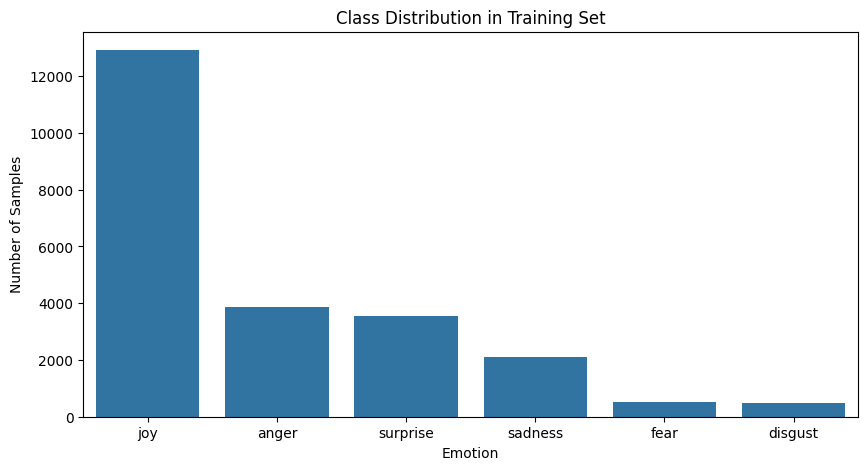

Total vocabulary size: 16760
Vocabulary size after pruning (min_df=5): 3753
Impact of pruning: Removing rare words drastically reduces vocabulary size, potentially avoiding overfitting.


In [14]:
# Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='ekman_label', order=train_df['ekman_label'].value_counts().index)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Samples")
plt.xlabel("Emotion")
plt.show()

# Vocabulary size (using CountVectorizer)
cv = CountVectorizer()
cv.fit(train_df['clean_text'])
print(f"Total vocabulary size: {len(cv.vocabulary_)}")

# Let's see the vocabulary size if we prune words that appear less than 5 times
cv_pruned = CountVectorizer(min_df=5)
cv_pruned.fit(train_df['clean_text'])
print(f"Vocabulary size after pruning (min_df=5): {len(cv_pruned.vocabulary_)}")
print("Impact of pruning: Removing rare words drastically reduces vocabulary size, potentially avoiding overfitting.")


### Top Unigrams per Class

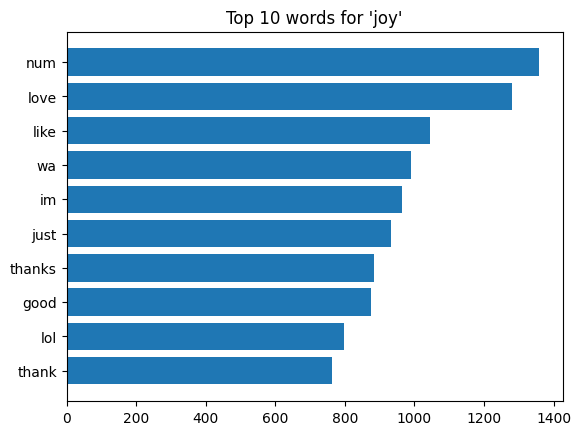

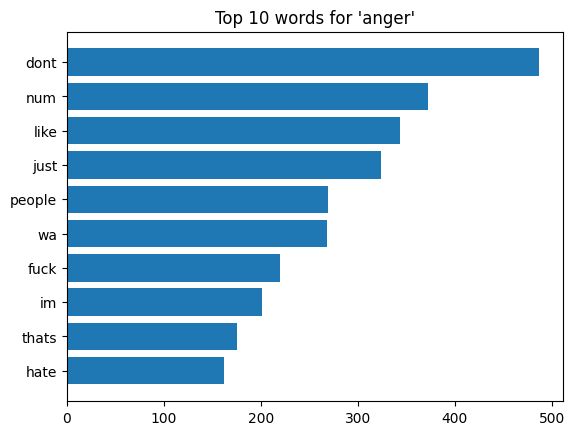

In [15]:
def plot_top_words(df, label, n=10):
    text_data = df[df['ekman_label'] == label]['clean_text']
    vec = CountVectorizer(stop_words='english').fit(text_data)
    bag_of_words = vec.transform(text_data)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:n]

    words, freqs = zip(*words_freq)
    plt.barh(words, freqs)
    plt.title(f"Top {n} words for '{label}'")
    plt.gca().invert_yaxis()
    plt.show()

plot_top_words(train_df, 'joy', n=10)
plot_top_words(train_df, 'anger', n=10)


## 4. Model Training and Evaluation (Multinomial Naive Bayes)
Training a Multinomial Naive Bayes model using a standard CountVectorizer.


In [16]:
# Vectorization
vectorizer = CountVectorizer(min_df=3)
X_train = vectorizer.fit_transform(train_df['clean_text'])
y_train = train_df['ekman_label']

X_test = vectorizer.transform(test_df['clean_text'])
y_test = test_df['ekman_label']

# Model Training
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Evaluation
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Average Accuracies
macro_acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {macro_acc:.4f}")


              precision    recall  f1-score   support

       anger       0.56      0.45      0.50       520
     disgust       0.78      0.18      0.30        76
        fear       0.83      0.13      0.22        77
         joy       0.71      0.90      0.79      1603
     sadness       0.64      0.37      0.47       259
    surprise       0.58      0.44      0.50       449

    accuracy                           0.67      2984
   macro avg       0.68      0.41      0.46      2984
weighted avg       0.66      0.67      0.64      2984

Accuracy: 0.6702


### Confusion Matrix

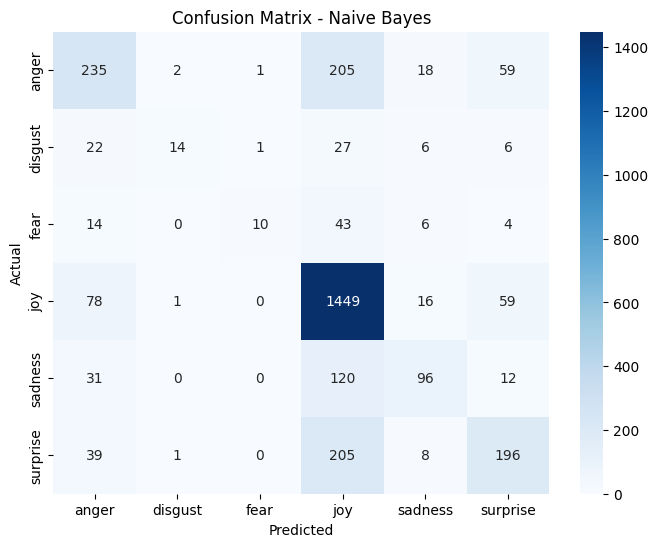

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_, cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()


### Analysis and Comparison to GoEmotions Paper
According to Table 6 in the GoEmotions paper (https://arxiv.org/pdf/2005.00547), the BERT model achieves an average Macro F1 of around 0.53 and Micro F1 of 0.69 on the Ekman classification task.
Our simple Naive Bayes model yields lower scores (e.g., lower macro F1 due to class imbalance, specifically struggling with minority classes like 'surprise' or 'fear'). 
The text normalization (lemmatization) and pruning help generalize better, but a Bag-of-Words approach lacks context and sequence information that BERT leverages.


## 5. Extra Task: Comparison of Vectorization Techniques
The comparison of  Unigrams (CountVectorizer), Unigrams + Bigrams (CountVectorizer), and TF-IDF (TfidfVectorizer).


Unigram (CountVectorizer):
  Macro F1: 0.4642
  Micro F1: 0.6702

Unigram + Bigram (CountVectorizer):
  Macro F1: 0.4689
  Micro F1: 0.6863

TF-IDF (Unigram):
  Macro F1: 0.2070
  Micro F1: 0.5744



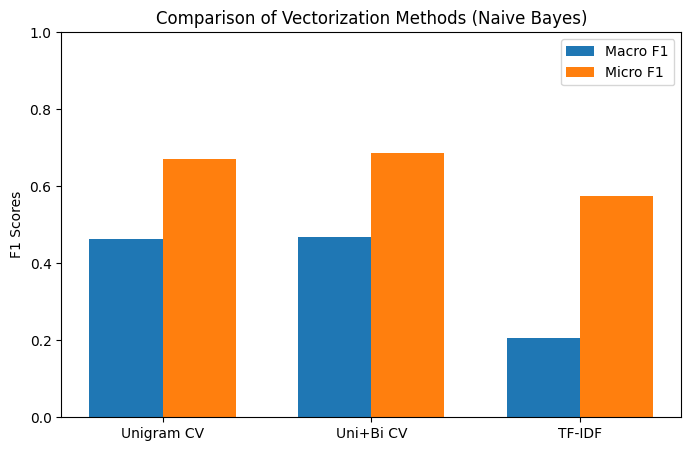

In [18]:
def evaluate_vectorizer(vec, name):
    X_train_v = vec.fit_transform(train_df['clean_text'])
    X_test_v = vec.transform(test_df['clean_text'])
    
    model = MultinomialNB()
    model.fit(X_train_v, y_train)
    y_pred_v = model.predict(X_test_v)
    
    macro_f1 = f1_score(y_test, y_pred_v, average='macro')
    micro_f1 = f1_score(y_test, y_pred_v, average='micro')
    print(f"{name}:")
    print(f"  Macro F1: {macro_f1:.4f}")
    print(f"  Micro F1: {micro_f1:.4f}\n")
    return macro_f1, micro_f1

vec_unigram = CountVectorizer(min_df=3)
vec_bigram = CountVectorizer(min_df=3, ngram_range=(1, 2))
vec_tfidf = TfidfVectorizer(min_df=3)

macro_1, micro_1 = evaluate_vectorizer(vec_unigram, "Unigram (CountVectorizer)")
macro_2, micro_2 = evaluate_vectorizer(vec_bigram, "Unigram + Bigram (CountVectorizer)")
macro_3, micro_3 = evaluate_vectorizer(vec_tfidf, "TF-IDF (Unigram)")

# Visualizing the comparison
labels = ['Unigram CV', 'Uni+Bi CV', 'TF-IDF']
macro_scores = [macro_1, macro_2, macro_3]
micro_scores = [micro_1, micro_2, micro_3]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, macro_scores, width, label='Macro F1')
rects2 = ax.bar(x + width/2, micro_scores, width, label='Micro F1')

ax.set_ylabel('F1 Scores')
ax.set_title('Comparison of Vectorization Methods (Naive Bayes)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.ylim(0, 1)
plt.show()


### Conclusions
- **Impact of Pruning & Tokenization**: Reducing the vocabulary with `min_df` and applying lemmatization avoids the model overfitting on rare words.
- **Bigrams vs Unigrams**: Adding bigrams marginally alters performance for Naive Bayes, often increasing sparsity which Naive Bayes might not fully utilize without sufficient data.
- **CountVectorizer vs TF-IDF**: TF-IDF often performs slightly worse or similarly in Multinomial Naive Bayes compared to CountVectorizer since MultinomialNB relies on term counts conceptually.
- **Overall**: While simple to train and interpretable, Naive Bayes falls short compared to Transformer-based models presented in the original paper.
